Running experiments... (visualization off for faster execution)

Starting run 1/5
Run 1: Success! Time: 0.00s, Path length: 19

Starting run 2/5
Run 2: Success! Time: 0.00s, Path length: 19

Starting run 3/5
Run 3: Success! Time: 0.00s, Path length: 19

Starting run 4/5
Run 4: Success! Time: 0.00s, Path length: 19

Starting run 5/5
Run 5: Success! Time: 0.00s, Path length: 19


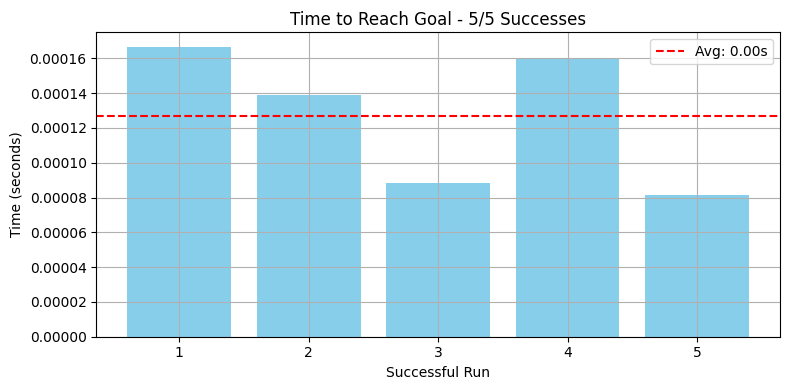


Success rate: 5/5
Average Time: 0.00s
Average Path Length: 19.0
Average Reward: 81.0
Timeouts: 0

Running single trial with visualization...


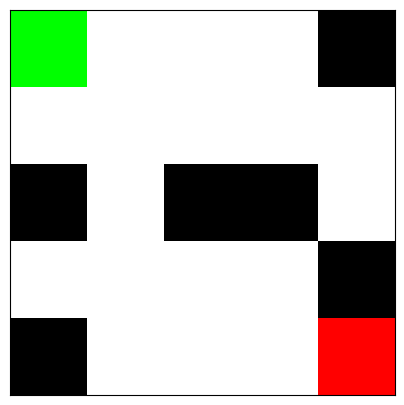

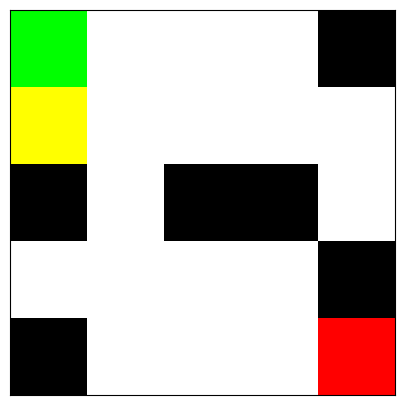

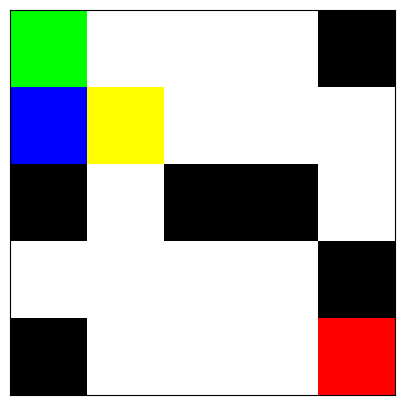

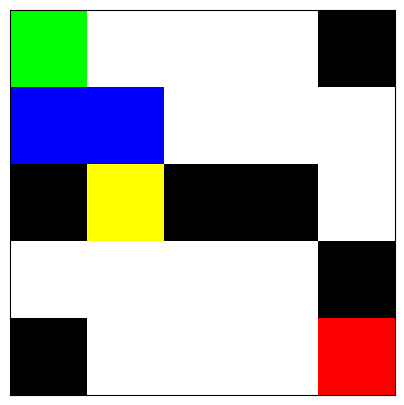

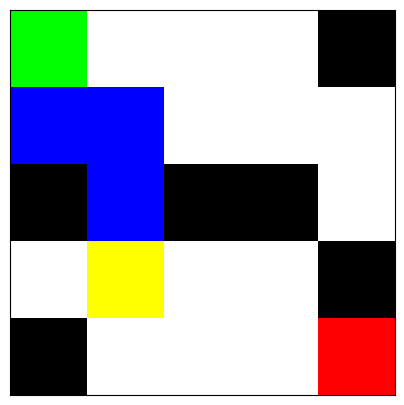

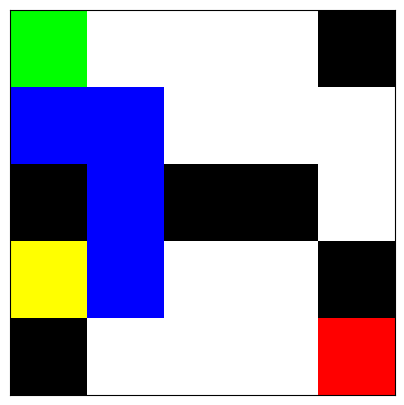

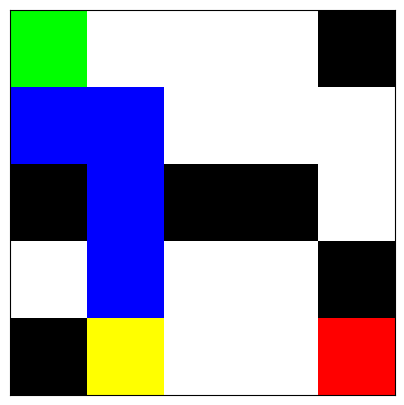

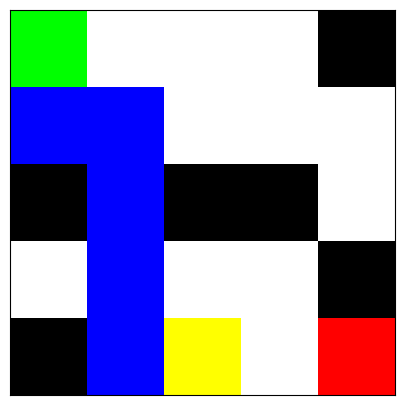

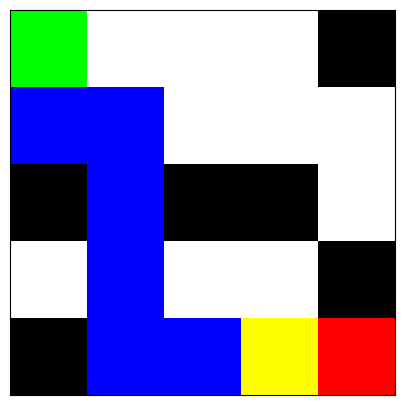

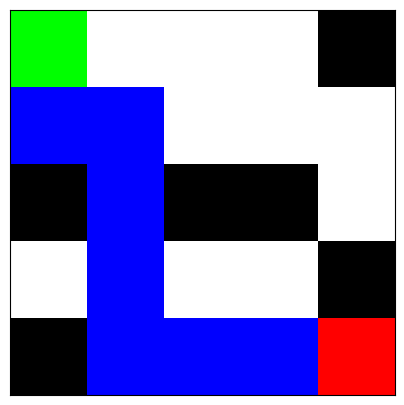

Success! Time: 0.99s, Path length: 9


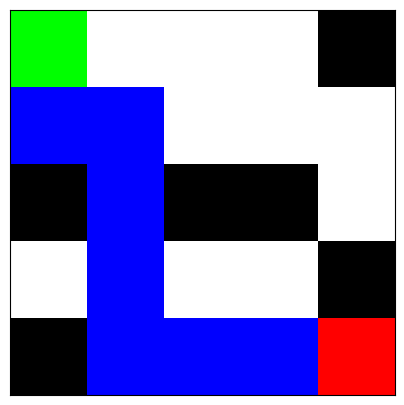

In [ ]:
import numpy as np
import time
import matplotlib.pyplot as plt
from collections import deque
import random
from IPython.display import clear_output

class AntMaze:
    def __init__(self, size=10, obstacle_density=0.2):
        self.size = size
        self.grid = np.zeros((size, size))
        self.start = (0, 0)
        self.goal = (size-1, size-1)
        self.ant_position = self.start
        self._generate_maze(obstacle_density)

    def _generate_maze(self, obstacle_density):
        for i in range(self.size):
            for j in range(self.size):
                if random.random() < obstacle_density and (i,j) != self.start and (i,j) != self.goal:
                    self.grid[i,j] = 1
        if not self._path_exists():
            self.grid = np.zeros((self.size, self.size))
            self._generate_maze(obstacle_density)

    def _path_exists(self):
        visited = set()
        queue = deque([self.start])
        while queue:
            x, y = queue.popleft()
            if (x, y) == self.goal:
                return True
            if (x, y) in visited:
                continue
            visited.add((x, y))
            for dx, dy in [(0,1), (1,0), (0,-1), (-1,0)]:
                nx, ny = x + dx, y + dy
                if 0 <= nx < self.size and 0 <= ny < self.size and self.grid[nx, ny] == 0:
                    queue.append((nx, ny))
        return False

    def reset(self):
        self.ant_position = self.start
        return self.ant_position

    def step(self, action):
        x, y = self.ant_position
        dx, dy = [(0, -1), (1, 0), (0, 1), (-1, 0)][action]
        nx, ny = x + dx, y + dy
        if 0 <= nx < self.size and 0 <= ny < self.size and self.grid[nx, ny] == 0:
            self.ant_position = (nx, ny)
        done = (self.ant_position == self.goal)
        reward = 100 if done else -1
        return self.ant_position, reward, done, {}

    def visualize(self, path=None):
        plt.figure(figsize=(5, 5))
        color_grid = np.zeros((self.size, self.size, 3))
        color_grid[self.grid == 0] = [1, 1, 1]
        color_grid[self.grid == 1] = [0, 0, 0]
        color_grid[self.start[0], self.start[1]] = [0, 1, 0]
        color_grid[self.goal[0], self.goal[1]] = [1, 0, 0]
        if path:
            for (x, y) in path[1:-1]:
                color_grid[x, y] = [0, 0, 1]
        if self.ant_position != self.start and self.ant_position != self.goal:
            color_grid[self.ant_position[0], self.ant_position[1]] = [1, 1, 0]
        plt.imshow(color_grid)
        plt.xticks([])
        plt.yticks([])
        plt.show()

def heuristic(position, goal):
    return abs(position[0] - goal[0]) + abs(position[1] - goal[1])

def ida_star(maze, max_time=60, visualize=False):
    start_time = time.time()
    start_node = maze.reset()
    goal_node = maze.goal
    threshold = heuristic(start_node, goal_node)
    path = [start_node]
    expanded_nodes = 0
    while True:
        if time.time() - start_time > max_time:
            return None, None, None, False
        result, new_threshold, nodes_expanded = depth_limited_search(
            path, 0, threshold, maze, goal_node, start_time, max_time, visualize)
        expanded_nodes += nodes_expanded
        if result == "found":
            end_time = time.time()
            total_time = end_time - start_time
            reward = 100 - len(path)
            return path, reward, total_time, True
        if result == "not_found":
            return None, None, None, False
        if result == "cutoff":
            threshold = new_threshold

def depth_limited_search(path, g, threshold, maze, goal_node, start_time, max_time, visualize):
    node = path[-1]
    f = g + heuristic(node, goal_node)
    if f > threshold:
        return "cutoff", f, 1
    if node == goal_node:
        return "found", threshold, 1
    min_cost = float('inf')
    nodes_expanded = 1
    for action in range(4):
        x, y = node
        dx, dy = [(0, -1), (1, 0), (0, 1), (-1, 0)][action]
        next_node = (x + dx, y + dy)
        if (0 <= next_node[0] < maze.size and 0 <= next_node[1] < maze.size and
            maze.grid[next_node[0], next_node[1]] == 0 and next_node not in path):
            if time.time() - start_time > max_time:
                return "not_found", None, nodes_expanded
            path.append(next_node)
            if visualize:
                maze.ant_position = next_node
                maze.visualize(path)
                time.sleep(0.05)
            result, new_threshold, expanded = depth_limited_search(
                path, g + 1, threshold, maze, goal_node, start_time, max_time, visualize)
            nodes_expanded += expanded
            if result == "found":
                return "found", threshold, nodes_expanded
            if result == "cutoff" and new_threshold < min_cost:
                min_cost = new_threshold
            path.pop()
    if min_cost != float('inf'):
        return "cutoff", min_cost, nodes_expanded
    else:
        return "not_found", None, nodes_expanded

def run_experiments(num_runs=5, maze_size=10, max_time=60, visualize=False):
    results = []
    for run in range(num_runs):
        print(f"\nStarting run {run+1}/{num_runs}")
        maze = AntMaze(size=maze_size)
        if visualize:
            print("Initial maze:")
            maze.visualize()
        path, reward, time_taken, success = ida_star(maze, max_time, visualize)
        if success:
            print(f"Run {run+1}: Success! Time: {time_taken:.2f}s, Path length: {len(path)}")
            results.append({
                'reward': reward,
                'time': time_taken,
                'path_length': len(path),
                'success': True
            })
        else:
            print(f"Run {run+1}: Failed to reach goal within {max_time} seconds")
            results.append({
                'reward': None,
                'time': max_time,
                'path_length': None,
                'success': False
            })
    return results

def plot_results(results, max_time):
    successful_runs = [r for r in results if r['success']]
    if successful_runs:
        times = [r['time'] for r in successful_runs]
        plt.figure(figsize=(8, 4))
        plt.bar(range(1, len(times)+1), times, color='skyblue')
        plt.axhline(y=np.mean(times), color='red', linestyle='--', label=f'Avg: {np.mean(times):.2f}s')
        plt.xlabel('Successful Run')
        plt.ylabel('Time (seconds)')
        plt.title(f'Time to Reach Goal - {len(successful_runs)}/{len(results)} Successes')
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()
        print(f"\nSuccess rate: {len(successful_runs)}/{len(results)}")
        print(f"Average Time: {np.mean(times):.2f}s")
        print(f"Average Path Length: {np.mean([r['path_length'] for r in successful_runs]):.1f}")
        print(f"Average Reward: {np.mean([r['reward'] for r in successful_runs]):.1f}")
    else:
        print("No successful runs to display.")
    print(f"Timeouts: {len(results) - len(successful_runs)}")

# Run experiments
print("Running experiments... (visualization off for faster execution)")
results = run_experiments(num_runs=5, maze_size=10, max_time=60, visualize=False)
plot_results(results, max_time=60)

# Single run with visualization
print("\nRunning single trial with visualization...")
maze = AntMaze(size=5)
maze.visualize()
path, reward, time_taken, success = ida_star(maze, max_time=60, visualize=True)
if success:
    print(f"Success! Time: {time_taken:.2f}s, Path length: {len(path)}")
    maze.visualize(path)
else:
    print("Failed to reach goal within time limit")
